<a href="https://colab.research.google.com/github/LCaravaggio/FelicidadDesigualdad/blob/main/OECD_to_LatLon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Los datos provienen de acá:
#https://data-explorer.oecd.org/vis?tenant=archive&df[ds]=DisseminateArchiveDMZ&df[id]=DF_CITIES&df[ag]=OECD&dq=BE002%2BBE003%2BBE005%2BCAN01%2BCAN02%2BCAN03%2BCAN05%2BCAN08%2BCAN09%2BCAN10%2BCAN12%2BCAN13%2BCAN14%2BCAN15%2BCAN16%2BFR001%2BFR003%2BFR004%2BFR006%2BFR007%2BFR008%2BFR009%2BFR010%2BFR011%2BFR013%2BFR026%2BFR032%2BFR203%2BFR205%2BFR215%2BIT001%2BIT002%2BIT003%2BIT004%2BIT005%2BIT006%2BIT007%2BIT008%2BIT009%2BIT010%2BIT011%2BIT012%2BIT028%2BNO001%2BPT001%2BPT002%2BSE001%2BSE002%2BSE003%2BUSA07%2BUSA08%2BUSA10%2BUSA16%2BUSA17%2BUSA18%2BUSA23%2BUSA24%2BUSA26%2BUSA27%2BUSA29%2BUSA32%2BUSA34%2BUSA36%2BUSA38%2BUSA39%2BUSA40%2BUSA43%2BUSA44%2BUSA47%2BUSA48%2BUSA50%2BUSA51%2BUSA52%2BUSA53%2BUSA55%2BUSA57%2BUSA58%2BUSA59%2BUSA60%2BUSA61%2BUSA62%2BUSA63%2BUSA64%2BUSA65%2BUSA66%2BUSA67%2BUSA68%2BUSA69%2BUSA70%2BUSA71%2BUSA72%2BUSA73%2BUSA74%2BUSA75%2BUSA76%2BUSA77%2BUSA78%2BUSA79%2BUSA80%2BUSA81%2BUSA82%2BUSA83%2BUSA84%2BUSA85%2BUSA86%2BUSA87%2BUSA88%2BUSA89%2BUSA91%2BUSA93%2BUSA94%2BAT001%2BAUS%2BAUS01%2BAUS02%2BAUT%2BAT002%2BAT003%2BAT004%2BAT005%2BAT006.INC%2BGINI&pd=2010%2C2022&to[TIME_PERIOD]=false&vw=tb

import pandas as pd
df=pd.read_csv('/content/Gini OECD.csv', encoding='cp1252', sep=';')
df = df.replace({'‚': 'é'}, regex=True)

In [2]:
import requests
from bs4 import BeautifulSoup

def Citytolatlon(city):
  api_url = 'http://www.geonames.org/search.html?q={}'
  response = requests.get(api_url + city)
  text=""
  if response.status_code == requests.codes.ok:
    soup = BeautifulSoup(response.text, 'html.parser')
    td_elements = soup.find_all('td', nowrap=True)
    count = 0
    for td in td_elements:
      text += td.get_text(strip=True)
      count+=1

      if count == 2:
          break
  else:
      print("Error:", response.status_code, response.text)
  return text

In [3]:
df['ciudad pais'] = df['Ciudad'] + ' ' + df['Pais']
df['latlon'] = [Citytolatlon(city) for city in df['ciudad pais']]

In [4]:
!pip install latlon3
from latlon import Latitude, Longitude, string2latlon

import re

class LL:
    __name__ = 'LatLon'
    def __init__(self, lat, lon, name=None):

        try:
            if lat.type() == 'GeoCoord':
                self.lat = lat
            else:
                raise AttributeError
        except AttributeError:
            self.lat = Latitude(lat)
        try:
            if lon.type() == 'GeoCoord':
                self.lon = lon
            else:
                raise AttributeError
        except AttributeError:
            self.lon = Longitude(lon)
        self.name = name

def toLatLong(texto):
    pattern = r"([NS])\s*(\d+)°\s*(\d+)'\s*(\d+)''([EW])\s*(\d+)°\s*(\d+)'\s*(\d+)''"
    matches = re.findall(pattern, texto.replace('′', "'"))

    if matches:
        direction1, degrees1, minutes1, seconds1, direction2, degrees2, minutes2, seconds2 = matches[0]
        output_str1 = f"{degrees1} {minutes1} {seconds1} {direction1}"
        output_str2 = f"{degrees2} {minutes2} {seconds2} {direction2}"

        # Asegúrate de que string2latlon sea la función correcta para convertir el formato
        return string2latlon(output_str1, output_str2, 'd% %m% %S% %H')
    else:
        return LL(lat=0, lon=0)  # Asegúrate de que LL esté definido

  Preparing metadata (setup.py) ... done
  Created wheel for latlon3: filename=latlon3-1.0.4-py3-none-any.whl size=31361 sha256=3249ab1510b212ff3ffa9c87fbfb7733241bbcc5b450cb2a6b23ff14c92f967b
  Stored in directory: /root/.cache/pip/wheels/08/0e/83/ddb89ac645c096005413387100c1f3af9a27b6b805f7057c8c
Successfully built latlon3


In [5]:
def get_latlon(row):
    latlon = toLatLong(row)
    return latlon.lat, latlon.lon

# Crear las nuevas columnas 'lat' y 'lon' en el DataFrame
df[['lat', 'lon']] = df['latlon'].apply(get_latlon).apply(pd.Series)

In [6]:
# Limpia cualquier carácter no numérico, como comas, grados, etc.
df['lat'] = df['lat'].replace(r'[^\d.-]', '', regex=True)
df['lon'] = df['lon'].replace(r'[^\d.-]', '', regex=True)

In [7]:
df['lon'] = df['lon'].astype(float)
df['lat'] = df['lat'].astype(float)

In [9]:
df = df[df['lon'] <= 40]

In [13]:
df['Gini'] = df['Gini'].str.replace(',', '.', regex=False).astype(float)

In [14]:
df.to_csv('Gini con latalon.csv')

In [11]:
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 90.2 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


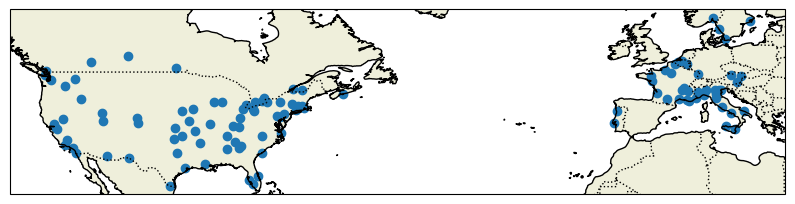

In [12]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd


# Crear el mapa
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# Añadir características del mapa
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Dibujar los puntos en el mapa con vmin y vmax basados en los datos
scatter = ax.scatter(df['lon'], df['lat'])

# Mostrar el mapa
plt.show()